In [3]:
import sys
from pathlib import Path
import pandas as pd
from src.features import add_distances_GC


PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

df = pd.read_csv('../data/df_with_features.csv').drop('Unnamed: 0', axis=1)
print(len(df)*0.8)
df.head()

import yfinance as yf


vix = yf.Ticker("^VIX")
vix_data = vix.history(start="2000-01-01", end="2024-12-31")
vix_close = vix_data['Close'].to_frame()

vix_close.columns = ['VIX']
vix_close.index = vix_close.index.tz_localize(None) 
df6 = df.copy()
df6['Date'] = df6['Date'].apply(lambda x: pd.to_datetime(x).tz_localize(None) if isinstance(x, str) else x)

# Set index et merge
df6_indexed = df6.set_index('Date')
df_with_vix = pd.concat([df6_indexed, vix_close], axis=1)
df_with_vix = df_with_vix.reset_index()

print(f"Missing VIX: {df_with_vix['VIX'].isna().sum()}")
df_with_vix.head()

df_with_vix['VIX_spike'] = df_with_vix['VIX'] / df_with_vix['VIX'].rolling(60).mean()


df_final = df_with_vix.copy()
df_final = add_distances_GC(df_final)
df_final['MA50'] = df_final['Close'].rolling(window=50).mean()
df_final['MA200'] = df_final['Close'].rolling(window=200).mean()
df_final['MA_velocity'] = (df_final['MA50'] - df_final['MA50'].shift(5)) - (df_final['MA200'] - df_final['MA200'].shift(5))
df_final['MA50_slope'] = df_final['MA50'].diff(10) / df_final['MA50']
df_final['Distance_normalized'] = df_final['Distance_GC'] / df_final['Volatility'].rolling(50).mean()
df_final['MA50_accel'] = df_final['MA50'].diff(5) - df_final['MA50'].diff(10)
df_final['MA_cross_momentum'] = df_final['MA50_accel'] / df_final['Distance_GC'].abs()


df_final = df_final.drop(['Close', 'High', 'Low', 'Open', 'Golden_Cross', 'Date', 'MA50', 'MA200', 'VIX', 'MA50_accel'], axis=1)
print(df_final.columns.tolist())

df_final.head(500)

5030.400000000001
Missing VIX: 0
['Return', 'Volatility', 'Cumulated_Return_5d', 'RSI14', 'Volume_ROC', 'ATR', 'Transition', 'VIX_spike', 'Distance_GC', 'MA_velocity', 'MA50_slope', 'Distance_normalized', 'MA_cross_momentum']


,Return,Volatility,Cumulated_Return_5d,RSI14,Volume_ROC,ATR,Transition,VIX_spike,Distance_GC,MA_velocity,MA50_slope,Distance_normalized,MA_cross_momentum
0,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.039106,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
2,0.001789,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.016072,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
4,0.058077,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.001914,0.011316,0.007214,49.387235,-66.770109,0.990111,0,0.799689,-0.035864,0.590002,0.012723,-2.928428,-12.916589
496,0.005491,0.011344,0.006756,43.164009,-59.114426,0.937582,0,0.792707,-0.034343,0.571538,0.012101,-2.823336,-12.953682
497,0.006069,0.010551,0.005780,46.521901,-47.658419,0.929453,0,0.772202,-0.032841,0.534223,0.011692,-2.721902,-13.987967
498,-0.000518,0.010164,0.015255,49.325544,-43.822715,0.892414,0,0.769969,-0.031100,0.558893,0.012388,-2.600822,-15.440460


In [ ]:
X = df_final.drop(['Transition'], axis=1)
y = df_final['Transition']
X_train = X.iloc[:5030]
X_test = X.iloc[5030:]
y_train = y.iloc[:5030]
y_test = y.iloc[5030:]

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print(f"F1 (transition class): {f1_score(y_test, y_pred):.3f}")

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1138
           1       0.47      0.85      0.60       120

    accuracy                           0.89      1258
   macro avg       0.73      0.87      0.77      1258
weighted avg       0.93      0.89      0.91      1258

F1 (transition class): 0.604


Seuil optimal : 0.907 → F1 = 0.714


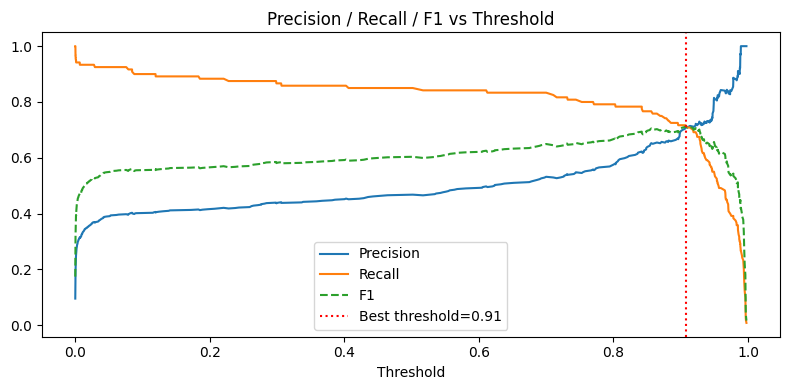

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1138
           1       0.71      0.72      0.71       120

    accuracy                           0.95      1258
   macro avg       0.84      0.84      0.84      1258
weighted avg       0.95      0.95      0.95      1258

F1 (transition class): 0.714


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

y_proba = xgb.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f"Seuil optimal : {best_threshold:.3f} → F1 = {f1_scores[best_idx]:.3f}")


plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1', linestyle='--')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best threshold={best_threshold:.2f}')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision / Recall / F1 vs Threshold')
plt.tight_layout()
plt.show()
y_pred_tuned = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned))
print(f"F1 (transition class): {f1_score(y_test, y_pred_tuned):.3f}")

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import yfinance as yf


PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.final_model import TransitionPredictor
from src.features import add_all_features, add_target_ma_cross, add_distances_GC
from src.data_loader import load_data

def add_target(df: pd.DataFrame, period=30):
    df1 = df.copy()
    df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})
    

    df1['Transition'] = 0
    

    label = df1['Golden_Cross'].iloc[0]
    indices = []
    for i in range(1, len(df1)):
        if df1['Golden_Cross'].iloc[i] != label:
            label = df1['Golden_Cross'].iloc[i]
            indices.append(i)

    for i in indices:
        start = max(0, i - period)  
        df1.loc[start:i-1, 'Transition'] = 1  
    
    return df1, indices


def preprocess_asset(ticker):

    df_ticker = load_data(ticker=ticker)
    
    df_ticker = add_all_features(df_ticker)
    df_ticker = add_target_ma_cross(df_ticker)
    df_ticker = add_distances_GC(df_ticker)
    df_ticker = add_target(df_ticker)[0]

    df_final = df_ticker.copy()
    
    df_final['MA50'] = df_final['Close'].rolling(window=50).mean()
    df_final['MA200'] = df_final['Close'].rolling(window=200).mean()
    df_final['MA_velocity'] = (df_final['MA50'] - df_final['MA50'].shift(5)) - (df_final['MA200'] - df_final['MA200'].shift(5))
    df_final['MA50_slope'] = df_final['MA50'].diff(10) / df_final['MA50']
    df_final['Distance_normalized'] = df_final['Distance_GC'] / df_final['Volatility'].rolling(50).mean()
    df_final['MA50_accel'] = df_final['MA50'].diff(5) - df_final['MA50'].diff(10)
    df_final['MA_cross_momentum'] = df_final['MA50_accel'] / df_final['Distance_GC'].abs()

    vix = yf.Ticker("^VIX")
    vix_data = vix.history(start="2000-01-01", end="2024-12-31")
    vix_close = vix_data['Close'].to_frame()
    vix_close.columns = ['VIX']
    vix_close.index = vix_close.index.tz_localize(None)  # Remove timezone

    df_vix = df_final.copy()
    
    df_vix['Date'] = pd.to_datetime(df_vix['Date']).dt.tz_localize(None)
    
    # Set index et merge
    df_indexed = df_vix.set_index('Date')
    df_with_vix = pd.concat([df_indexed, vix_close], axis=1)
    df_with_vix = df_with_vix.reset_index()

    print(f"Missing VIX: {df_with_vix['VIX'].isna().sum()}")

    df_with_vix['VIX_spike'] = df_with_vix['VIX'] / df_with_vix['VIX'].rolling(60).mean()

    df_with_vix = df_with_vix.drop(['Close', 'High', 'Low', 'Open', 'Golden_Cross', 'Date',
                                    'MA50', 'MA200', 'VIX', 'MA50_accel', 'Dividends',
                                     'Stock Splits', 'Capital Gains', 'Volume', 'Log Return',
                                      'Stoch_K'], axis=1)

    return df_with_vix

#Test w SPY

spy_test = preprocess_asset('SPY')
print(spy_test.columns.tolist())
spy_test.head(500)



Missing VIX: 0
['Return', 'Volatility', 'Cumulated_Return_5d', 'RSI14', 'Volume_ROC', 'ATR', 'Distance_GC', 'Transition', 'MA_velocity', 'MA50_slope', 'Distance_normalized', 'MA_cross_momentum', 'VIX_spike']


C:\Users\alexa\AppData\Local\Temp\ipykernel_24144\2413616593.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})


,Return,Volatility,Cumulated_Return_5d,RSI14,Volume_ROC,ATR,Distance_GC,Transition,MA_velocity,MA50_slope,Distance_normalized,MA_cross_momentum,VIX_spike
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
1,-0.039106,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
2,0.001789,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
3,-0.016072,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
4,0.058077,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.001914,0.011315,0.007214,49.387308,-66.770109,0.990108,-0.035864,0,0.590003,0.012723,-2.928438,-12.916522,0.799689
496,0.005491,0.011344,0.006755,43.163863,-59.114426,0.937580,-0.034343,0,0.571538,0.012101,-2.823346,-12.953670,0.792707
497,0.006068,0.010551,0.005779,46.521472,-47.658419,0.929450,-0.032841,0,0.534223,0.011692,-2.721914,-13.987997,0.772202
498,-0.000517,0.010164,0.015255,49.325813,-43.822715,0.892407,-0.031100,0,0.558892,0.012388,-2.600833,-15.440525,0.769969


In [ ]:
def validate_cross_assets_xgb(tickers: list):
    results = []
    
    print("="*70)
    print("Training XGB on SPY...")
    print("="*70)
    
    spy_df = preprocess_asset('SPY')
    column_order = ['Return', 'Volatility', 'Cumulated_Return_5d', 'RSI14', 
                   'Volume_ROC', 'ATR', 'Transition', 'VIX_spike', 'Distance_GC', 
                   'MA_velocity', 'MA50_slope', 'Distance_normalized', 'MA_cross_momentum']
    spy_df = spy_df[column_order]
    
    X_spy = spy_df.drop(['Transition'], axis=1)
    y_spy = spy_df['Transition']
    X_train_spy = X_spy.iloc[:5030]
    X_val_spy   = X_spy.iloc[5030:]
    y_train_spy = y_spy.iloc[:5030]
    y_val_spy   = y_spy.iloc[5030:]
    
    neg, pos = (y_train_spy == 0).sum(), (y_train_spy == 1).sum()
    
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=neg/pos,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='aucpr',
        verbosity=0
    )
    xgb.fit(X_train_spy, y_train_spy)

    #optimal threshold from spy but on the other assets
    y_proba_val = xgb.predict_proba(X_val_spy)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val_spy, y_proba_val)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_threshold = thresholds[np.argmax(f1_scores[:-1])]
    print(f"Seuil optimal (SPY val) : {best_threshold:.3f}")
    
    for ticker in tickers:
        print(f"\n{'#'*70}")
        print(f"# Testing on {ticker}")
        print(f"{'#'*70}")
        
        df = preprocess_asset(ticker)
        df = df[column_order]
        X = df.drop(['Transition'], axis=1)
        y = df['Transition']
        X_test = X.iloc[5030:]
        y_test  = y.iloc[5030:]
        
        print(f"{ticker} - Test set size: {len(y_test)}")
        print(f"{ticker} - Test positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
        
        y_proba = xgb.predict_proba(X_test)[:, 1]
        y_pred  = (y_proba >= best_threshold).astype(int)
        
        print(classification_report(y_test, y_pred))
        
        results.append({
            'Asset':       ticker,
            'Precision':   precision_score(y_test, y_pred, zero_division=0),
            'Recall':      recall_score(y_test, y_pred, zero_division=0),
            'F1':          f1_score(y_test, y_pred, zero_division=0),
            'N_samples':   len(y_test),
            'N_positive':  int(y_test.sum()),
            'Pct_positive': y_test.mean() * 100
        })
    
    results_df = pd.DataFrame(results)
    print("\n" + "="*70)
    print("CROSS-ASSET VALIDATION SUMMARY (XGBoost + threshold tuning)")
    print("="*70)
    print(results_df.to_string(index=False))
    
    return results_df

tickers = ['SPY', 'DIA', 'QQQ']
results_xgb = validate_cross_assets_xgb(tickers)

Training XGB on SPY...


C:\Users\alexa\AppData\Local\Temp\ipykernel_24144\2413616593.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})


Missing VIX: 0
Seuil optimal (SPY val) : 0.889

######################################################################
# Testing on SPY
######################################################################


C:\Users\alexa\AppData\Local\Temp\ipykernel_24144\2413616593.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})


Missing VIX: 0
SPY - Test set size: 1258
SPY - Test positives: 120 (9.5%)
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1138
           1       0.70      0.73      0.72       120

    accuracy                           0.94      1258
   macro avg       0.84      0.85      0.84      1258
weighted avg       0.95      0.94      0.94      1258


######################################################################
# Testing on DIA
######################################################################


C:\Users\alexa\AppData\Local\Temp\ipykernel_24144\2413616593.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})


Missing VIX: 0
DIA - Test set size: 1258
DIA - Test positives: 120 (9.5%)
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1138
           1       0.75      0.67      0.70       120

    accuracy                           0.95      1258
   macro avg       0.86      0.82      0.84      1258
weighted avg       0.94      0.95      0.95      1258


######################################################################
# Testing on QQQ
######################################################################
Missing VIX: 0
QQQ - Test set size: 1258
QQQ - Test positives: 102 (8.1%)
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1156
           1       0.77      0.69      0.73       102

    accuracy                           0.96      1258
   macro avg       0.87      0.83      0.85      1258
weighted avg       0.96      0.96      0.96      1258


CROSS-ASSET VALIDATION SUMMARY (XGBoo

C:\Users\alexa\AppData\Local\Temp\ipykernel_24144\2413616593.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Golden_Cross'] = df1['Golden_Cross'].replace({'Non-Bullish': 0, 'Bullish': 1})


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
X_spy = df_final.drop(['Transition'], axis=1)
y_spy = df_final['Transition']
X_train_spy = X_spy.iloc[:5030]
X_val_spy   = X_spy.iloc[5030:]
y_train_spy = y_spy.iloc[:5030]
y_val_spy   = y_spy.iloc[5030:]
y_proba_spy = xgb.predict_proba(X_val_spy)[:, 1]

print("=" * 55)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<10} {'N_pred'}")
print("=" * 55)

for thresh in np.arange(0.3, 0.95, 0.05):
    y_pred_t = (y_proba_spy >= thresh).astype(int)
    n_pred = y_pred_t.sum()
    if n_pred > 0:
        p = precision_score(y_val_spy, y_pred_t, zero_division=0)
        r = recall_score(y_val_spy, y_pred_t, zero_division=0)
        f = f1_score(y_val_spy, y_pred_t, zero_division=0)
        print(f"{thresh:<12.2f} {p:<12.3f} {r:<12.3f} {f:<10.3f} {n_pred}")
    else:
        print(f"{thresh:<12.2f} {'N/A':<12} {'N/A':<12} {'N/A':<10} 0")

Threshold    Precision    Recall       F1         N_pred
0.30         0.439        0.867        0.583      237
0.35         0.444        0.858        0.585      232
0.40         0.452        0.858        0.592      228
0.45         0.464        0.850        0.600      220
0.50         0.468        0.850        0.604      218
0.55         0.479        0.842        0.610      211
0.60         0.493        0.842        0.622      205
0.65         0.510        0.833        0.633      196
0.70         0.529        0.825        0.645      187
0.75         0.545        0.800        0.649      176
0.80         0.576        0.792        0.667      165
0.85         0.639        0.767        0.697      144
0.90         0.699        0.717        0.708      123
